# GROUP 1 PROJECT - DATA ANALYSIS 

----------------
----------------

# API connection 

**Source:**  SMARD / Bundesnetzagentur -> ENTSO-E

As on SMARD at this moment is only possible to download data, and not to access it through an API and on webpage is written this: "SMARD receives the data directly from the European Network of Transmission System Operators for Electricity (ENTSO-E). Only data verified by the Bundesnetzagentur is published on SMARD.", ENTSO-E API is used instead.

Original code owner: Killan 

Owner: Darija 

Added Germany and saving to csv


In [18]:
from entsoe import EntsoePandasClient
import pandas as pd
#DL the module entsoe 

client = EntsoePandasClient(
    api_key='5bcf63bf-87d7-4aa5-8bfb-040cbc4c4af0'
)
##This is Kilian's token 


start = pd.Timestamp(
    '2025-01-01',
    tz='Europe/Brussels'
)

end = pd.Timestamp(
    '2025-03-01',
    tz='Europe/Brussels'
)

es = client.query_day_ahead_prices(
    'ES',
    start=start,
    end=end
)

fr = client.query_day_ahead_prices(
    'FR',
    start=start,
    end=end
)

de = client.query_day_ahead_prices(
    'DE_LU',
    start=start,
    end=end
)

df = pd.DataFrame({
    'Spain': es,
    'France': fr,
    'Germany': de
})

# df["hour"] = df.index.hour
# df["day_of_week"] = df.index.dayofweek
# df["month"] = df.index.month
# df["date"] = df.index.date

print(df.head())



# -----------------------------
# SAVE TO CSV
# -----------------------------
import os

os.makedirs("data", exist_ok=True)
df.to_csv("data/day_ahead_prices_2025_Q1.csv")

print("CSV saved successfully ✅")
print(df.head())

-------------
-------------

# Statistical Analysis

Owner: Darija


In [19]:
# -----------------------------
# READ DATA FROM CSV
# -----------------------------

df = pd.read_csv(
    "data/day_ahead_prices_2025_Q1.csv",
    index_col=0,
    parse_dates=True
)

print("CSV loaded successfully ✅")
print(df.head())

In [20]:
def statistical_summary(df, country):
    return {
        "mean": df[country].mean(),
        "median": df[country].median(),
        "std": df[country].std(),
        "variance": df[country].var(),
        "min": df[country].min(),
        "max": df[country].max(),
        "range": df[country].max() - df[country].min(),
        "skewness": df[country].skew(),
        "kurtosis": df[country].kurtosis(),
        "q25": df[country].quantile(0.25),
        "q50": df[country].quantile(0.50),
        "q75": df[country].quantile(0.75),
    }

stats_es = statistical_summary(df, "Spain")
stats_fr = statistical_summary(df, "France")
stats_de = statistical_summary(df, "Germany")

stats_df = pd.DataFrame({
    "Spain": stats_es,
    "France": stats_fr,
    "Germany": stats_de
})

stats_df

,Spain,France,Germany
mean,102.205688,111.952802,120.970713
median,109.400000,118.560000,120.370000
std,46.290052,45.831333,50.550235
variance,2142.768883,2100.511048,2555.326275
min,0.000000,0.400000,-1.010000
max,240.000000,473.280000,583.400000
range,240.000000,472.880000,584.410000
skewness,-0.326810,0.139881,1.449417
kurtosis,-0.204253,3.128884,9.846298
q25,72.880000,89.940000,93.860000


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_boxplot(df):
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df[['Spain', 'France', 'Germany']])
    plt.title("Electricity Price Distribution (Quartiles & Median)")
    plt.ylabel("€/MWh")
    plt.grid(True)
    plt.show()

plot_boxplot(df)

In [22]:
def plot_distribution(df):
    plt.figure(figsize=(10,6))
    sns.histplot(df['Spain'], kde=True, label='Spain', alpha=0.5)
    sns.histplot(df['France'], kde=True, label='France', alpha=0.5)
    sns.histplot(df['Germany'], kde=True, label='Germany', alpha=0.5)
    plt.legend()
    plt.title("Price Distribution Comparison")
    plt.show()

plot_distribution(df)

In [23]:
def risk_index(df, country):
    return df[country].std() / df[country].mean()

print("Risk ES:", risk_index(df, "Spain"))
print("Risk FR:", risk_index(df, "France"))
print("Risk DE:", risk_index(df, "Germany"))

--------
--------

# Volatility Analysis

In [24]:
##VOLATILITY ANALYSIS

# --- 3. Volatility Calculation ---
def calculate_volatility(df, country):
    # Global volatility
    volatility = {
        "std_dev": df[country].std(),
        "mean": df[country].mean(),
        "min": df[country].min(),
        "max": df[country].max(),
        "range": df[country].max() - df[country].min(),
        "coef_variation": (df[country].std() / df[country].mean()) * 100,
    }

    # Hourly volatility
    hourly_volatility = df.groupby("hour")[country].agg(["mean", "std", "min", "max"])

    # Daily volatility (by day of the week)
    daily_volatility = df.groupby("day_of_week")[country].agg(["mean", "std", "min", "max"])

    # Monthly volatility
    monthly_volatility = df.groupby("month")[country].agg(["mean", "std", "min", "max"])

    return volatility, hourly_volatility, daily_volatility, monthly_volatility

# Calculate for Spain and France
volatility_es, hourly_vol_es, daily_vol_es, monthly_vol_es = calculate_volatility(df, 'Spain')
volatility_fr, hourly_vol_fr, daily_vol_fr, monthly_vol_fr = calculate_volatility(df, 'France')

# --- 4. Visualizations ---
def plot_comparative_volatility(df):
    plt.figure(figsize=(18, 12))

    # 4.1. Time series of prices (Spain vs France)
    plt.subplot(2, 2, 1)
    df['Spain'].plot(label='Spain', color='blue', alpha=0.7)
    df['France'].plot(label='France', color='red', alpha=0.7)
    plt.title("Hourly Price Evolution (Spain vs France)")
    plt.ylabel("Price (€/MWh)")
    plt.legend()
    plt.grid(True)

    # 4.2. Price distribution (Spain vs France)
    plt.subplot(2, 2, 2)
    sns.histplot(df['Spain'], bins=30, kde=True, color='blue', label='Spain', alpha=0.5)
    sns.histplot(df['France'], bins=30, kde=True, color='red', label='France', alpha=0.5)
    plt.title("Price Distribution")
    plt.xlabel("Price (€/MWh)")
    plt.legend()

    # 4.3. Hourly volatility (standard deviation)
    plt.subplot(2, 2, 3)
    hourly_std = df.groupby("hour")[['Spain', 'France']].std()
    hourly_std.plot(kind='bar', title="Hourly Volatility (Standard Deviation)", alpha=0.7)
    plt.xlabel("Hour of the Day")
    plt.ylabel("Standard Deviation")

    # 4.4. Weekly volatility (standard deviation by day of the week)
    plt.subplot(2, 2, 4)
    daily_std = df.groupby("day_of_week")[['Spain', 'France']].std()
    days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    daily_std.plot(kind='bar', title="Volatility by Day of the Week", alpha=0.7)
    plt.xticks(range(7), days)
    plt.ylabel("Standard Deviation")

    plt.tight_layout()
    plt.show()

    # 4.5. Boxplot by month (Spain vs France)
    plt.figure(figsize=(12, 6))
    df_melted = df.reset_index().melt(id_vars=['hour', 'day_of_week', 'month', 'date'],
                                      value_vars=['Spain', 'France'],
                                      var_name='Country', value_name='Price')
    sns.boxplot(x="month", y="Price", hue="Country", data=df_melted)
    plt.title("Price Distribution by Month (Spain vs France)")
    plt.xlabel("Month")
    plt.ylabel("Price (€/MWh)")
    plt.grid(True)
    plt.show()

# --- 5. Display Results ---
print("--- Global Volatility (Spain) ---")
for k, v in volatility_es.items():
    print(f"{k}: {v:.2f}")

print("\n--- Global Volatility (France) ---")
for k, v in volatility_fr.items():
    print(f"{k}: {v:.2f}")

# Generate visualizations
plot_comparative_volatility(df)

KeyError: 'hour'

---------------
---------------
 # Heatmaps: another way to study electricity prices

In [25]:
df = df.iloc[1:]  #To start with the 1st hours of the 1st of January
df.head()

,Spain,France,Germany
2025-01-01 00:00:00+00:00,131.59,18.92,1.60
2025-01-01 01:00:00+00:00,131.49,16.66,0.00
2025-01-01 02:00:00+00:00,131.42,13.10,-0.01
2025-01-01 03:00:00+00:00,120.49,5.90,-0.01
2025-01-01 04:00:00+00:00,112.30,9.27,-0.06


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

#Creation of two columns : Day and Hour
df["Date"] = df.index.strftime("%Y-%m-%d")  # Format : "2025-01-15"
df["Hour"] = df.index.strftime("%H:00")     # Format : "23:00"
pivot_df = df.pivot(index="Hour", columns="Date", values=["France", "Spain","Germany"]) #Hour becomes the index and the dates are columns
pivot_df.head()

C:\Users\darij\AppData\Local\Temp\ipykernel_31896\70169758.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date"] = df.index.strftime("%Y-%m-%d")  # Format : "2025-01-15"
C:\Users\darij\AppData\Local\Temp\ipykernel_31896\70169758.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Hour"] = df.index.strftime("%H:00")     # Format : "23:00"


France                                                         \
Date  2025-01-01 2025-01-02 2025-01-03 2025-01-04 2025-01-05 2025-01-06   
Hour                                                                      
00:00      18.92      44.10      95.18     101.00      70.50       8.35   
01:00      16.66      44.70      89.94      95.53      64.81       5.23   
02:00      13.10      42.92      87.67      94.33      46.70       3.52   
03:00       5.90      40.15      84.06      96.62      43.87       3.52   
04:00       9.27      52.51      92.25     102.63      36.61       5.61   

                                                   ...    Germany             \
Date  2025-01-07 2025-01-08 2025-01-09 2025-01-10  ... 2025-02-19 2025-02-20   
Hour                                               ...                         
00:00       6.66      69.50      49.90      80.25  ...      99.29      85.20   
01:00      12.54      59.97      51.86      72.09  ...      99.60      84.56   
02:00       5.59      53.00      25.61      69.94  ...      97.29      83.64   
03:00       0.40      59.52      13.01      70.07  ...      94.50      82.18   
04:00      12.49      70.20      30.29      85.06  ...      97.48      83.84   

                                                                         \
Date  2025-02-21 2025-02-22 2025-02-23 2025-02-24 2025-02-25 2025-02-26   
Hour                                                                      
00:00      74.99      48.62      84.99      67.99      89.91     119.82   
01:00      79.80      47.96      86.21      40.98      93.39     116.94   
02:00      83.40      42.62      83.63      37.10      93.86     115.98   
03:00      82.40      41.20      85.77      65.34      97.43     116.56   
04:00      82.03      49.15      87.33      70.03     105.78     117.27   

                             
Date  2025-02-27 2025-02-28  
Hour                         
00:00     103.81     110.54  
01:00     101.24     109.38  
02:00      99.60     106.93  
03:00     100.43     112.03  
04:00     105.87     112.63  

[5 rows x 177 columns]

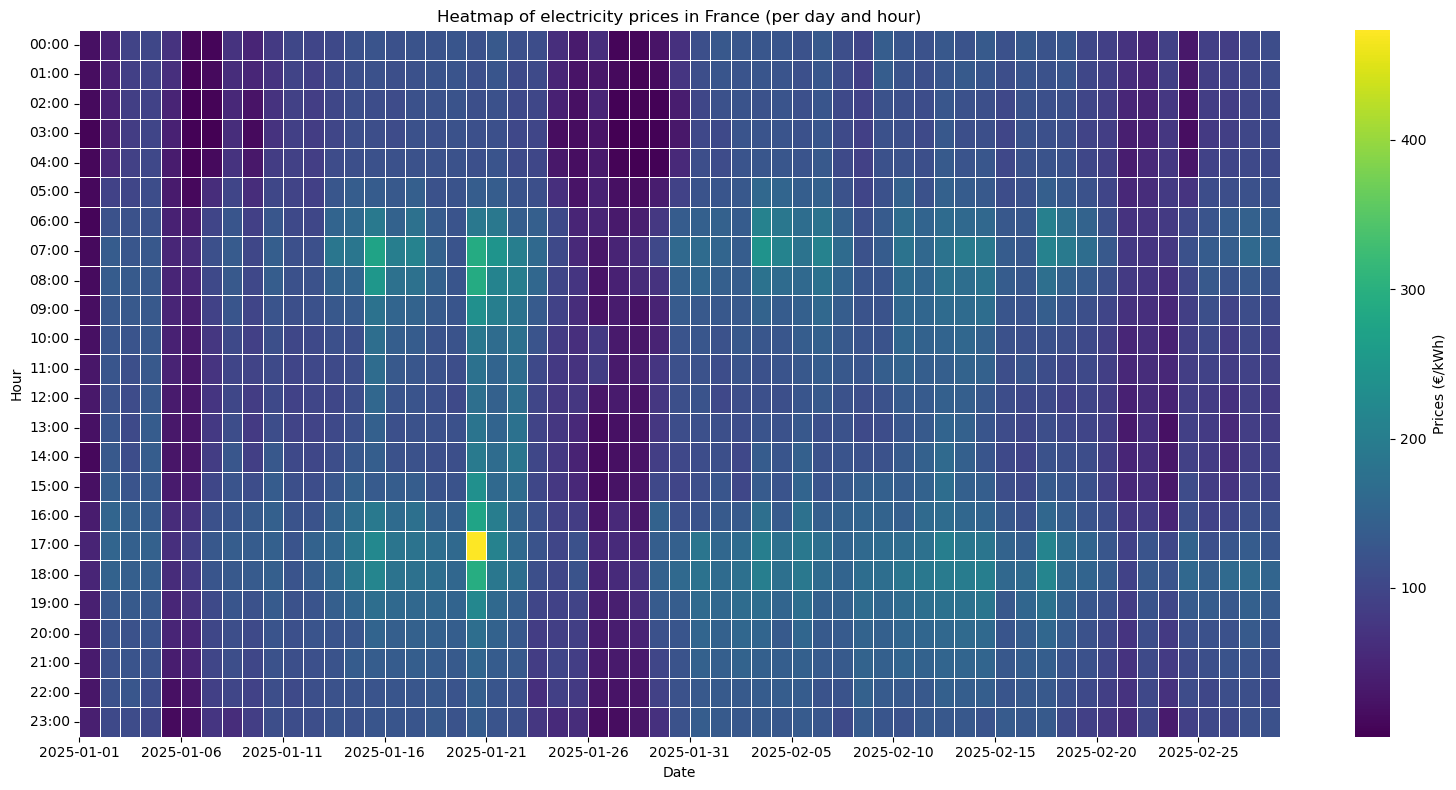

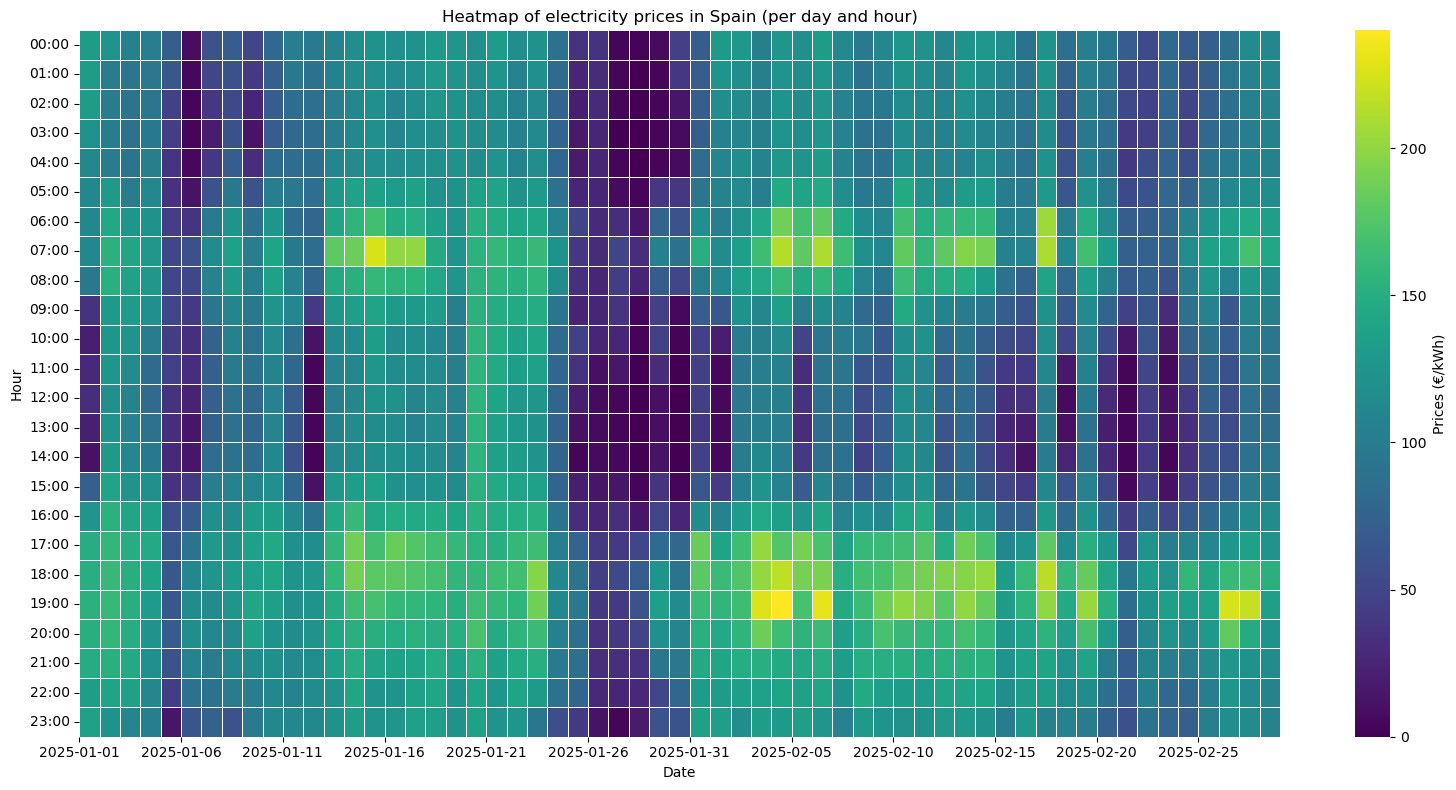

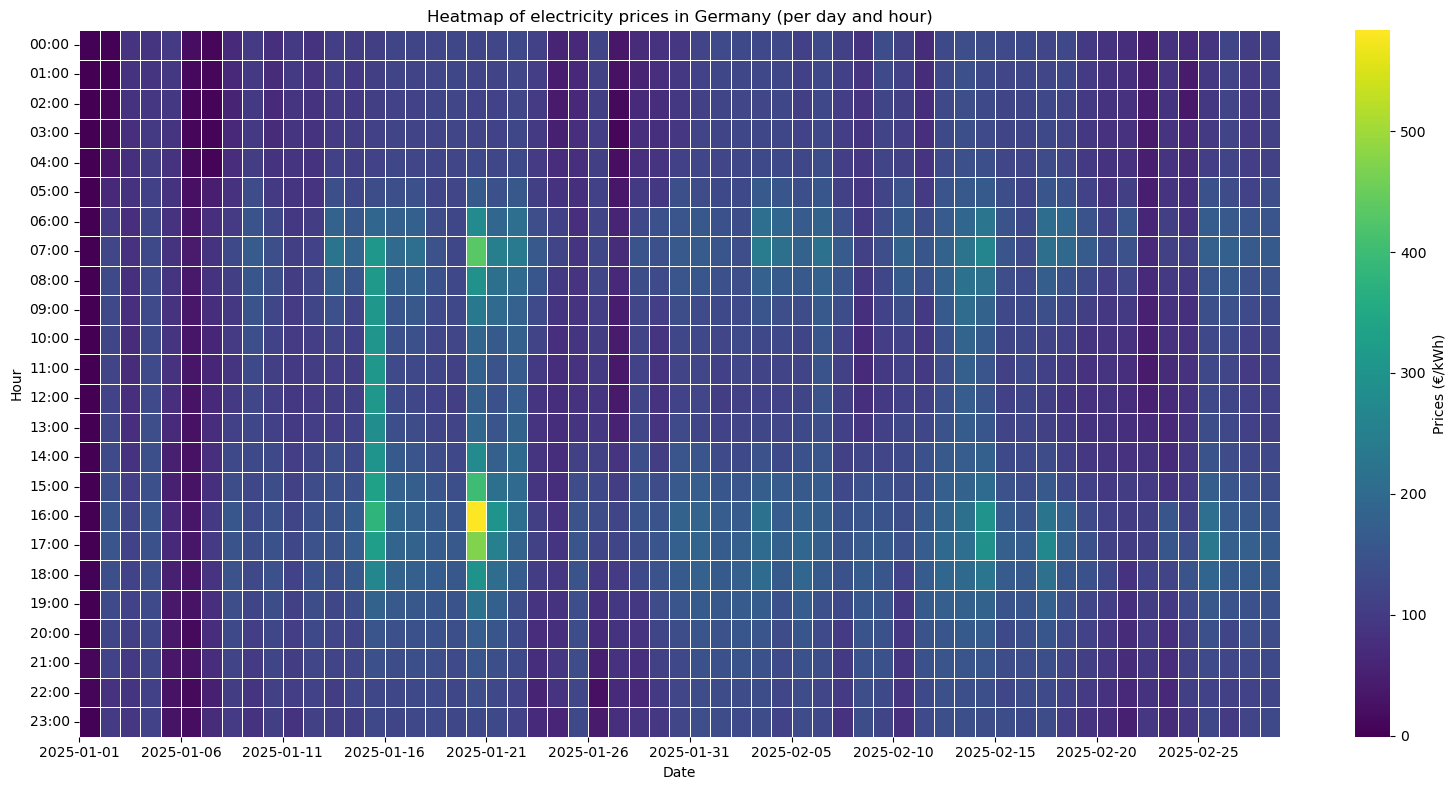

In [27]:
#Heatmap with x axis = day ; y axis = hour ; colour (heat) = prices
for country in ["France", "Spain","Germany"]:
    plt.figure(figsize=(16, 8))
    sns.heatmap(
        pivot_df[country],
        cmap="viridis", #the color code
        annot=False, #prices won't appear for each set {day, hour} or else too much information
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={'label': 'Prices (€/kWh)'} #Color (heat) legend
    )
    plt.title(f"Heatmap of electricity prices in {country} (per day and hour)")
    plt.xlabel("Date")
    plt.ylabel("Hour")
    Xticks=pivot_df["France"].columns #we'll have to select the ticks for the x axis that will appear
    plt.xticks(
        ticks=range(0, len(Xticks), 5),  #Their position
        labels=Xticks[::5],  #Only 1 out of 5 ticks will be displayed with the dates
        rotation=0) #Writing horizontally the dates
    plt.tight_layout()
    plt.show()


Those heatmaps show the electricity prices in each country, over three months, for each hour of the day. The more yellow the square is, the more expensive the electricity was that day at that time!

A first analysis of these maps is that, in general, Spain has more expensive electricity. This must be caused by the lack of flexibility caused by the important amount of solar and wind. 

Let's thus go more into details with those differences with other heatmaps:

In [28]:
#dataframe new columns for differences between country
df['Spain_France']=df['Spain']-df['France']
df['France_Germany']=df['France']-df['Germany']
df['Spain_Germany']=df['Spain']-df['Germany']
Min_spread={'SF':df['Spain_France'].min(), "SG": df['Spain_Germany'].min(), "FG": df['France_Germany'].min()}
Max_spread={'SF':df['Spain_France'].max(), "SG": df['Spain_Germany'].max(), "FG": df['France_Germany'].max()}
df.head()

C:\Users\darij\AppData\Local\Temp\ipykernel_31896\3632570690.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Spain_France']=df['Spain']-df['France']
C:\Users\darij\AppData\Local\Temp\ipykernel_31896\3632570690.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['France_Germany']=df['France']-df['Germany']
C:\Users\darij\AppData\Local\Temp\ipykernel_31896\3632570690.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

,Spain,France,Germany,Date,Hour,Spain_France,France_Germany,Spain_Germany
2025-01-01 00:00:00+00:00,131.59,18.92,1.60,2025-01-01,00:00,112.67,17.32,129.99
2025-01-01 01:00:00+00:00,131.49,16.66,0.00,2025-01-01,01:00,114.83,16.66,131.49
2025-01-01 02:00:00+00:00,131.42,13.10,-0.01,2025-01-01,02:00,118.32,13.11,131.43
2025-01-01 03:00:00+00:00,120.49,5.90,-0.01,2025-01-01,03:00,114.59,5.91,120.50
2025-01-01 04:00:00+00:00,112.30,9.27,-0.06,2025-01-01,04:00,103.03,9.33,112.36


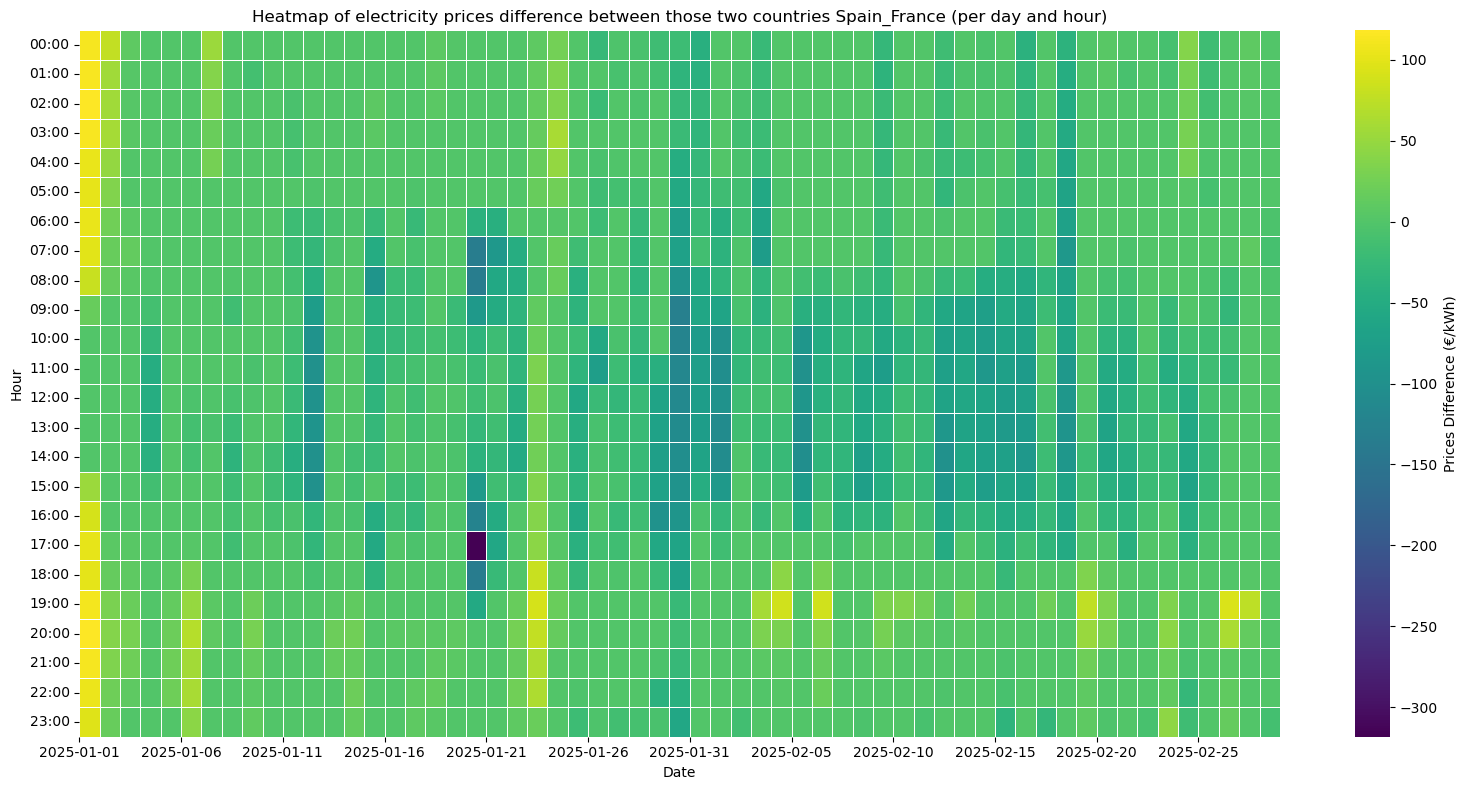

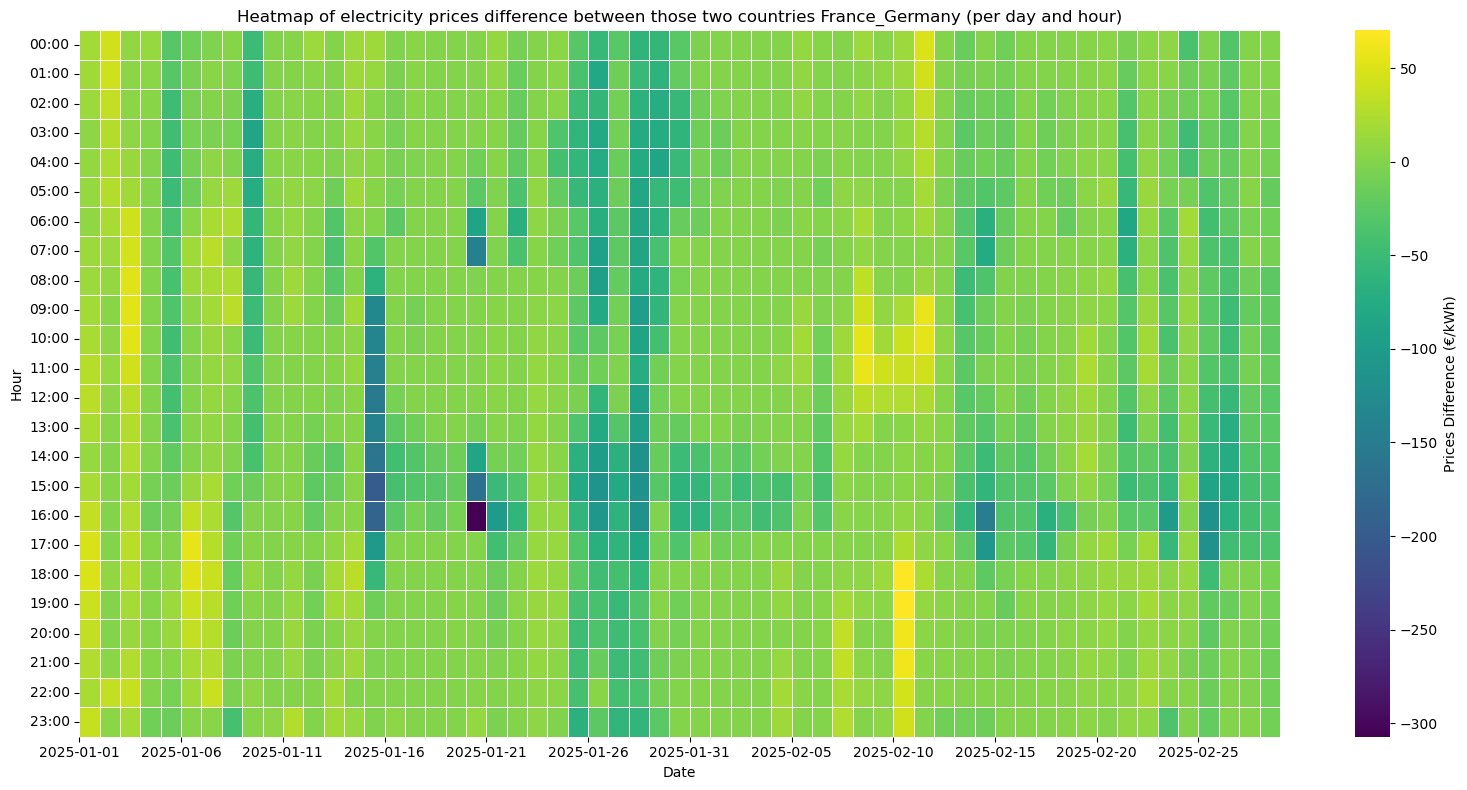

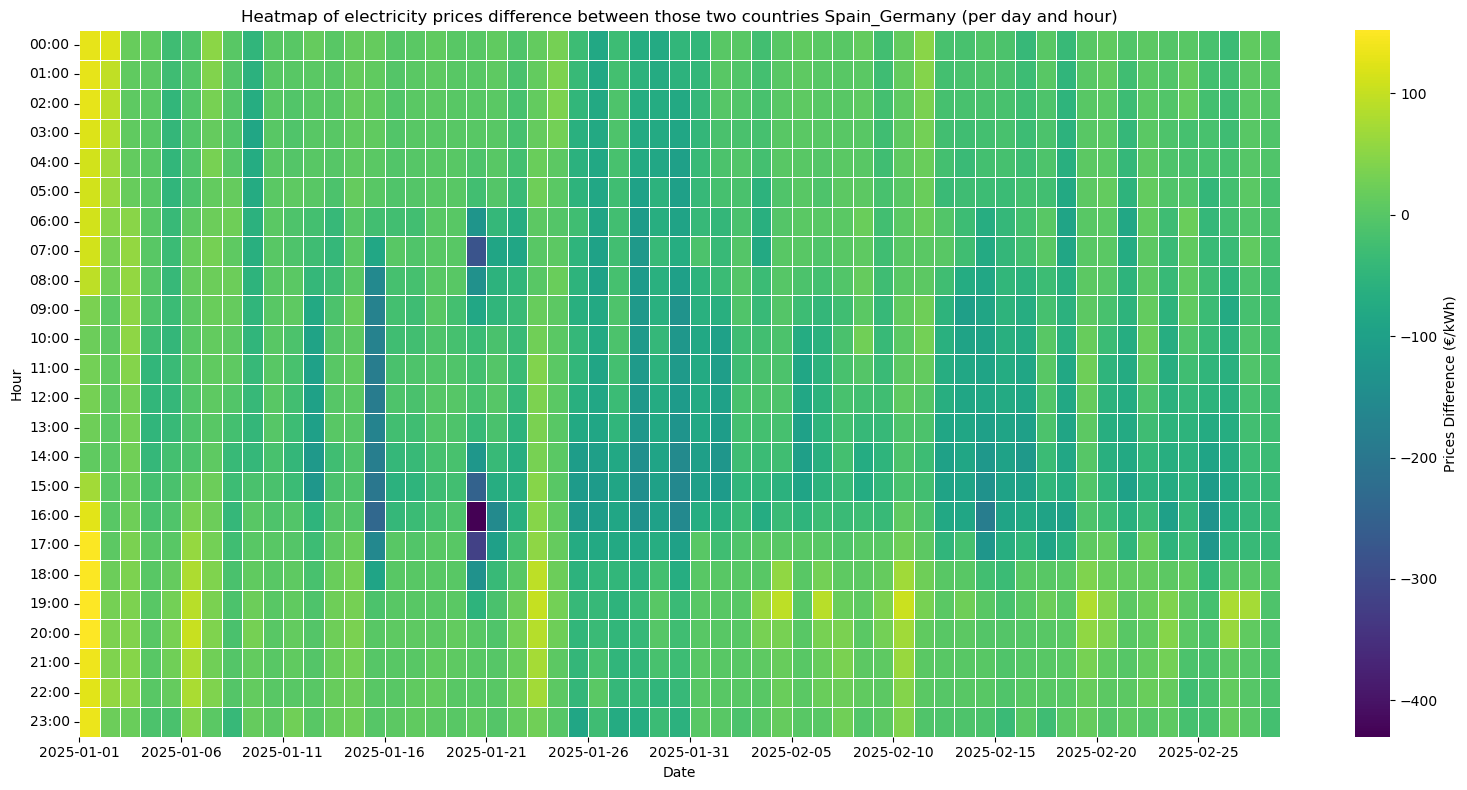

In [29]:
for countries in ["Spain_France", "France_Germany","Spain_Germany"]:
    pivot = df.pivot(index="Hour", columns="Date", values=[countries]) #Hour becomes the index and the dates are columns
    plt.figure(figsize=(16, 8))
    sns.heatmap(
                pivot[countries],
                cmap="viridis", #the color code
                annot=False, #prices won't appear for each set {day, hour} or else too much information
                fmt=".2f",
                linewidths=0.5,
                cbar_kws={'label': 'Prices Difference (€/kWh)'} #Color (heat) legend
            )
    plt.title(f"Heatmap of electricity prices difference between those two countries {countries} (per day and hour)")
    plt.xlabel("Date")
    plt.ylabel("Hour")

    plt.xticks(
                ticks=range(0, len(Xticks), 5),  #Their position
                labels=Xticks[::5],  #Only 1 out of 5 ticks will be displayed with the dates
                rotation=0) #Writing horizontally the dates
    plt.tight_layout()
    plt.show()

What is interesting pointing out here are the different colour (heat) scales: the prices difference seams to be the greatest between Spain and Germany across those three months.

Moreover, what we observe easily is that, during daytime hours (between 9 AM and 6 PM), Spain has cheaper prices than both other countries. It isn't the case at other hours (due to the lack of solar production). 

------------
------------
 # Simulate a simplified battery storage system

In [30]:
# Bonus Section: Energy Storage Simulation (Miguel's Contribution).
class SimuladorBateria:
    def __init__(self, capacidad_max=100.0, potencia_max=50.0, eficiencia=0.85):
        """
        Defines the technical parameters of the energy storage system.
        capacidad_max: Maximum battery capacity in MWh.
        potencia_max: Maximum charging or discharging power in MW per hour.
        eficiencia: Round-trip efficiency of the storage cycle (85%).
        """
        self.capacidad_max = capacidad_max  
        self.potencia_max = potencia_max    
        self.eficiencia = eficiencia

In [31]:
def ejecutar_simulacion(self, df_precios, columna_pais):
        estado_carga = 0.0
        beneficio_acumulado = 0.0
        acciones = []
        historial_carga = []
        ingresos_gastos = []
        
        # Statistical thresholds calculated from hourly market data
        umbral_carga = df_precios[columna_pais].quantile(0.30)
        umbral_descarga = df_precios[columna_pais].quantile(0.70)
        
        for precio in df_precios[columna_pais]:
            # CHARGING RULE: Buy when cheap or take advantage of negative prices
            if (precio <= 0 or precio < umbral_carga) and estado_carga < self.capacidad_max:
                energia_a_cargar = min(self.potencia_max, self.capacidad_max - estado_carga)
                estado_carga += energia_a_cargar
                coste_operacion = energia_a_cargar * precio
                beneficio_acumulado -= coste_operacion
                
                acciones.append('Cargar')
                ingresos_gastos.append(-coste_operacion)

In [32]:
            # DISCHARGING RULE: Sell during peak hours (high market prices) 
            elif precio > umbral_descarga and estado_carga > 0:
                energia_a_descargar = min(self.potencia_max, estado_carga)
                estado_carga -= energia_a_descargar
                # Apply efficiency: energy recovered is equal to energy discharged * efficiency
                ingreso_operacion = (energia_a_descargar * self.eficiencia) * precio
                beneficio_acumulado += ingreso_operacion
                
                acciones.append('Descargar')
                ingresos_gastos.append(ingreso_operacion)

SyntaxError: invalid syntax (313516868.py, line 2)